# Patent Citation Network

U.S. patent dataset is maintained by the [National Bureau of Economic Research](http://www.nber.org/). The data set spans 37 years (January 1, 1963 to December 30, 1999), and includes all the utility patents granted during that period, totaling 3,923,922 patents. The citation graph includes all citations made by patents granted between 1975 and 1999, totaling 16,522,438 citations. For the patents dataset there are 1,803,511 nodes for which we have no information about their citations (we only have the in-links).

The data was originally released by [NBER](http://www.nber.org/patents/). The dataset can be found at this link: [Stanford Patent Citation Network](https://snap.stanford.edu/data/cit-Patents.html)

## Import Packages

In [6]:
!pip install -q node2vec
!pip install -qI gensim

In [20]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from random import randint
from node2vec import Node2Vec
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

%matplotlib inline

## Import data

In [3]:
patent = pd.read_csv(
    "http://snap.stanford.edu/data/cit-Patents.txt.gz",
    compression="gzip",
    sep="\t",
    names=["start_node", "end_node"],
    skiprows=5
)

In [ ]:
patent.head()

,start_node,end_node
0,3858241,1324234
1,3858241,3398406
2,3858241,3557384
3,3858241,3634889
4,3858242,1515701


In [ ]:
patent.shape

(16518947, 2)

## Build Recommendation System

build a recommendation system based on Node2Vec with the patent information, remember to do a descriptive analysis and apply visualizations.

Also, remember that when making a recommendation about which patent should be associated with another, make a visualization of the recommendation.

### Creación del grafo

In [4]:
G = nx.from_pandas_edgelist(patent, 'start_node', 'end_node', create_using=nx.Graph())#Preguntar al profesor si es necesario que el grafo sea dirigido para representar las citaciones is no cambiar por Graph() o DiGraph()

In [5]:
G_Dir = nx.from_pandas_edgelist(patent, 'start_node', 'end_node', create_using=nx.DiGraph()) #Preguntar al profesor si es necesario que el grafo sea dirigido para representar las citaciones is no cambiar por Graph() o DiGraph()

In [ ]:
print("Total number of graph nodes:", G.number_of_nodes())
print("Total number of graph edges:", G.number_of_edges())

Total number of graph nodes: 3774767
Total number of graph edges: 16518947


Grafo dirigido

In [ ]:
print("Total number of graph nodes:", G_Dir.number_of_nodes())
print("Total number of graph edges:", G_Dir.number_of_edges())

Total number of graph nodes: 3774767
Total number of graph edges: 16518947


In [ ]:
# Promedio de grado
np.mean([d for _, d in G.degree()])

8.752300208198282

 En promedio, cada patente está conectada (relacionada o citada) con otras 8.75 patentes.

Las siguiente metricas aplican para si el grafo es dirigido, que es  el que se ha contruido. Se puede ver el grado de entrada y salida promedio de los nodos

Promedio de grado de entrada: 4.376150104099141
Promedio de grado de salida: 4.376150104099141


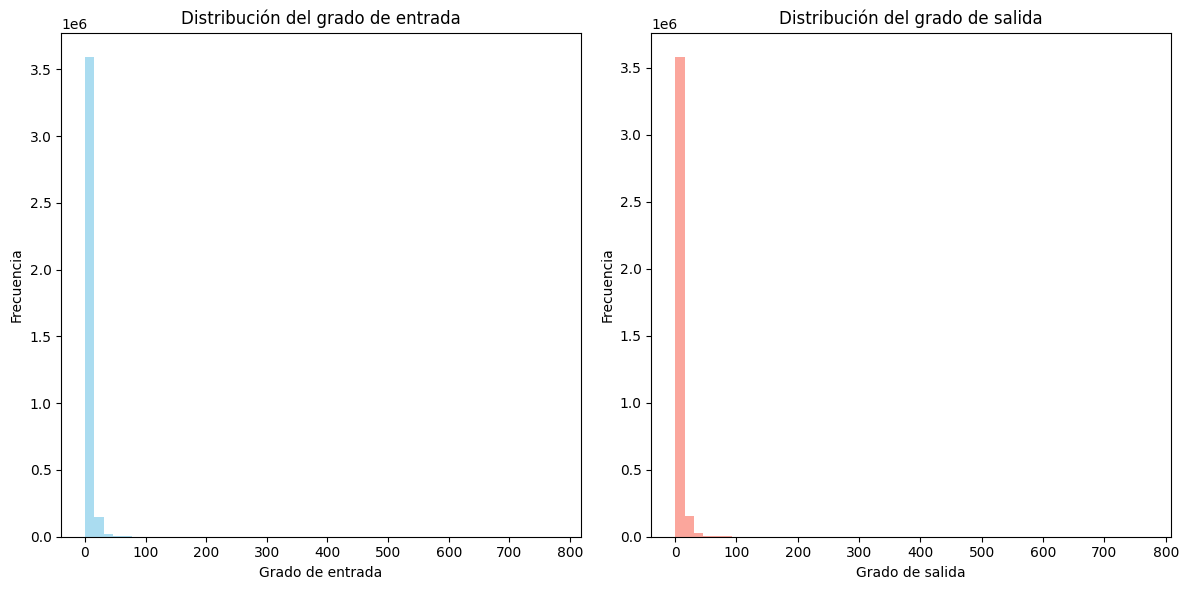

In [ ]:
# Calcular el grado de entrada (in-degree) como una lista
in_degrees = [d for _, d in G_Dir.in_degree()]
avg_in_degree = np.mean(in_degrees)

# Calcular el grado de salida (out-degree) como una lista
out_degrees = [d for _, d in G_Dir.out_degree()]
avg_out_degree = np.mean(out_degrees)

print(f"Promedio de grado de entrada: {avg_in_degree}")
print(f"Promedio de grado de salida: {avg_out_degree}")

# Extraer los valores de los grados de entrada y salida
in_degree_values = in_degrees  # Ya son listas, no es necesario usar .values()
out_degree_values = out_degrees

# Visualización de la distribución de los grados de entrada y salida
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Histograma de grados de entrada
plt.subplot(1, 2, 1)
plt.hist(in_degree_values, bins=50, color='skyblue', alpha=0.7)
plt.title('Distribución del grado de entrada')
plt.xlabel('Grado de entrada')
plt.ylabel('Frecuencia')

# Histograma de grados de salida
plt.subplot(1, 2, 2)
plt.hist(out_degree_values, bins=50, color='salmon', alpha=0.7)
plt.title('Distribución del grado de salida')
plt.xlabel('Grado de salida')
plt.ylabel('Frecuencia')

# Mostrar la visualización
plt.tight_layout()
plt.show()


 Identificar las patentes más citadas (mayor grado de entrada)

In [ ]:
# Obtener el grado de entrada como un diccionario (nodo -> grado)
in_degrees_dict = dict(G_Dir.in_degree())

# Ordenar patentes por el grado de entrada (más citadas)
most_cited_patents = sorted(in_degrees_dict.items(), key=lambda x: x[1], reverse=True)

# Mostrar las 10 patentes más citadas
print("Top 10 patentes más citadas:")
for patent, degree in most_cited_patents[:10]:
    print(f"Patente: {patent}, Citaciones recibidas: {degree}")


Top 10 patentes más citadas:
Patente: 4723129, Citaciones recibidas: 779
Patente: 4463359, Citaciones recibidas: 716
Patente: 4740796, Citaciones recibidas: 678
Patente: 4345262, Citaciones recibidas: 658
Patente: 4558333, Citaciones recibidas: 654
Patente: 4313124, Citaciones recibidas: 633
Patente: 4683195, Citaciones recibidas: 630
Patente: 4459600, Citaciones recibidas: 613
Patente: 4683202, Citaciones recibidas: 605
Patente: 3953566, Citaciones recibidas: 411


Identificar las patentes que más citan (mayor grado de salida)

In [ ]:
# Obtener el grado de entrada como un diccionario (nodo -> grado)
out_degrees_dict = dict(G_Dir.out_degree())


# Ordenar patentes por el grado de salida (más citadoras)
most_citing_patents = sorted(out_degrees_dict.items(), key=lambda x: x[1], reverse=True)

# Mostrar las 10 patentes que más citan
print("Top 10 patentes que más citan:")
for patent, degree in most_citing_patents[:10]:
    print(f"Patente: {patent}, Citaciones hechas: {degree}")


Top 10 patentes que más citan:
Patente: 5795784, Citaciones hechas: 770
Patente: 5887243, Citaciones hechas: 745
Patente: 5856194, Citaciones hechas: 737
Patente: 5855655, Citaciones hechas: 626
Patente: 5891229, Citaciones hechas: 626
Patente: 5908495, Citaciones hechas: 624
Patente: 5858586, Citaciones hechas: 623
Patente: 6008268, Citaciones hechas: 623
Patente: 5885337, Citaciones hechas: 621
Patente: 5837429, Citaciones hechas: 612


Grado de centralidad

In [ ]:
degree_centrality = nx.centrality.degree_centrality(
    G
)  # save results in a variable to use again
(sorted(degree_centrality.items(), key=lambda item: item[1], reverse=True))[:8]

[(4723129, 0.0002100792472963887),
 (5795784, 0.00020398615437354262),
 (5887243, 0.00019736322728349252),
 (5856194, 0.0001955088076982785),
 (4463359, 0.00019206488561145245),
 (4740796, 0.00018332262185258636),
 (4345262, 0.00017511019226092424),
 (4558333, 0.00017484527517732222)]

In [ ]:
(sorted(G.degree, key=lambda item: item[1], reverse=True))[:8]

[(4723129, 793),
 (5795784, 770),
 (5887243, 745),
 (5856194, 738),
 (4463359, 725),
 (4740796, 692),
 (4345262, 661),
 (4558333, 660)]

Saber el nodos con mayor grado

In [ ]:
# Obtener los grados totales (suma de in-degree y out-degree) para cada nodo
total_degrees = dict(G.degree())  # G.degree() da el grado total de cada nodo (entrada + salida)

# Encontrar el nodo con el mayor grado total
max_total_degree_node = max(total_degrees, key=total_degrees.get)

# Mostrar el nodo con mayor grado total y su valor
print(f"Nodo con mayor grado total: {max_total_degree_node}")
print(f"Grado total del nodo: {total_degrees[max_total_degree_node]}")


Nodo con mayor grado total: 4723129
Grado total del nodo: 793


graficar con respecto al nodo 4723129 dado que es el que tiene mayor grado

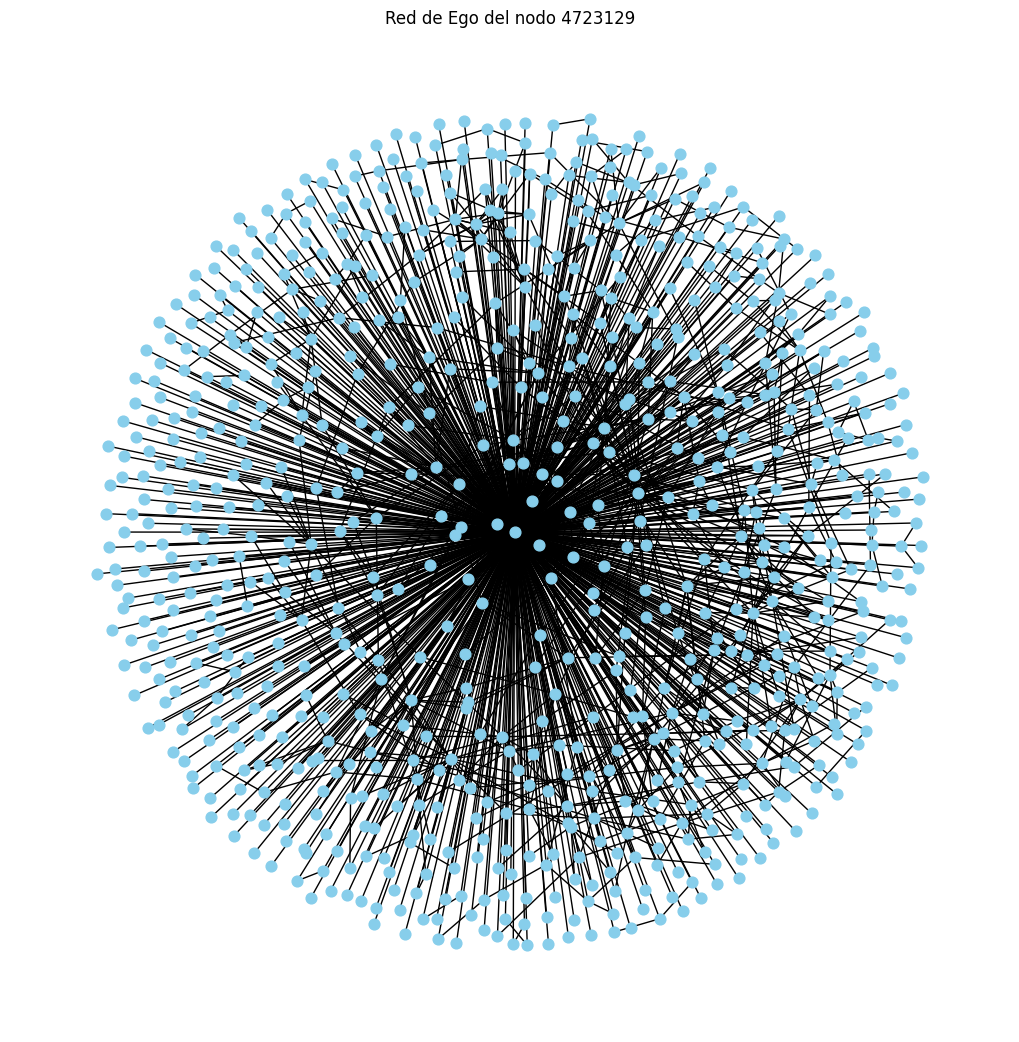

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Selecciona un nodo de interés (puedes usar el nodo más citado o cualquier otro criterio)
ego_node = 4723129  # Reemplaza con un nodo que te interese

# Extraer la red de ego (subgrafo centrado en el nodo ego)
ego_network = nx.ego_graph(G, ego_node)

# Visualización de la red de ego (subgrafo)
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(ego_network)  # Puede ser más manejable con subgrafos pequeños
nx.draw(ego_network, pos, node_color="skyblue", with_labels=False, node_size=60, font_size=8)
plt.title(f"Red de Ego del nodo {ego_node}")
plt.show()


In [ ]:
print(f"Subgrafo con los nodos más conectados tiene {ego_network.number_of_nodes()} nodos y {ego_network.number_of_edges()} aristas.")

Subgrafo con los nodos más conectados tiene 794 nodos y 1538 aristas.


Grafo de ego dirigido

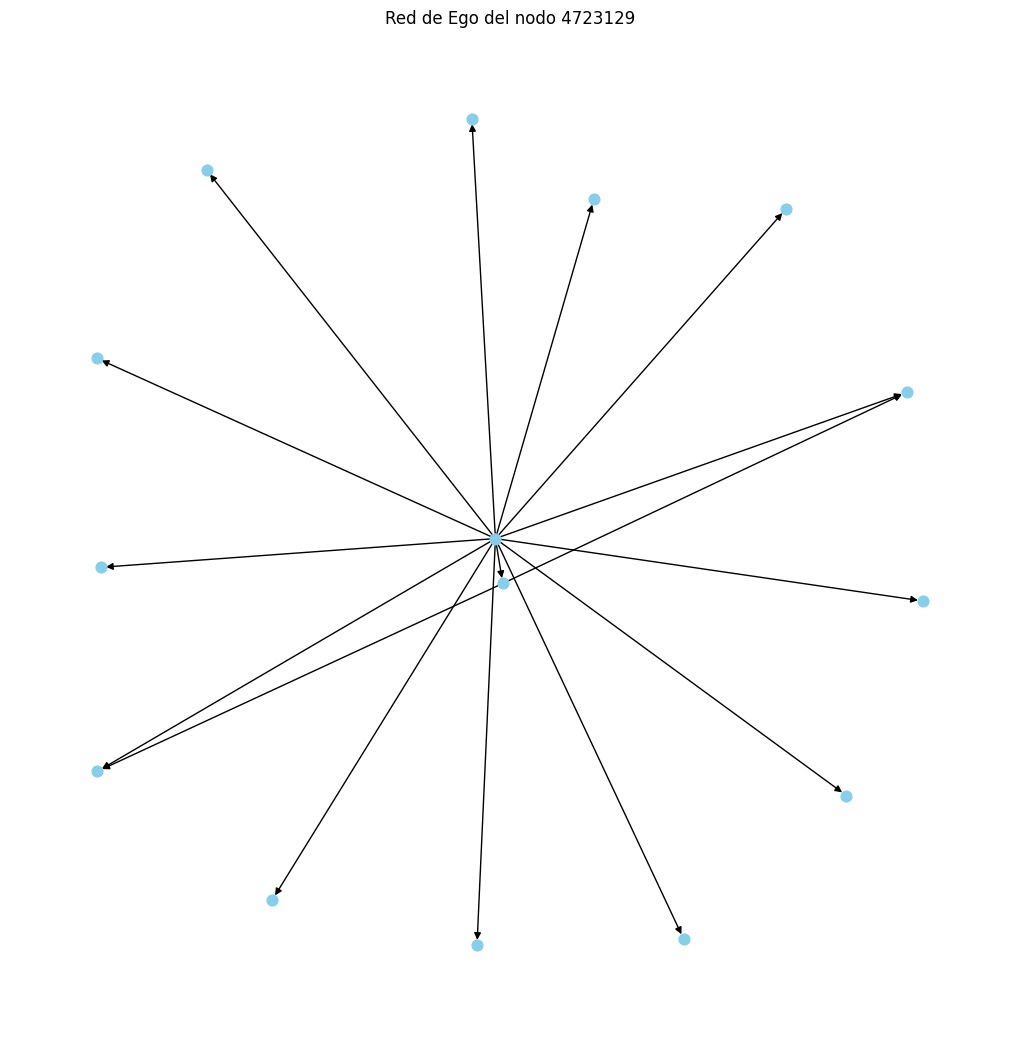

Subgrafo con los nodos más conectados tiene 15 nodos y 16 aristas.


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Selecciona un nodo de interés (puedes usar el nodo más citado o cualquier otro criterio)
ego_node = 4723129  # Reemplaza con un nodo que te interese

# Extraer la red de ego (subgrafo centrado en el nodo ego)
ego_network_dir = nx.ego_graph(G_Dir, ego_node)

# Visualización de la red de ego (subgrafo)
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(ego_network_dir)  # Puede ser más manejable con subgrafos pequeños
nx.draw(ego_network_dir, pos, node_color="skyblue", with_labels=False, node_size=60, font_size=8)
plt.title(f"Red de Ego del nodo {ego_node}")
plt.show()

print(f"Subgrafo con los nodos más conectados tiene {ego_network_dir.number_of_nodes()} nodos y {ego_network_dir.number_of_edges()} aristas.")

Generar un subgrafo dado el volumen del grado

In [ ]:
# Obtener los grados totales (suma de in-degree y out-degree)
total_degrees = dict(G.degree())

# Ordenar los nodos por grado y seleccionar los 10,000 con mayor grado
top_nodes = [node for node, degree in sorted(total_degrees.items(), key=lambda x: x[1], reverse=True)[:1000]]

# Crear un subgrafo con esos nodos
subgraph = G.subgraph(top_nodes)

print(f"Subgrafo con los nodos más conectados tiene {subgraph.number_of_nodes()} nodos y {subgraph.number_of_edges()} aristas.")


Subgrafo con los nodos más conectados tiene 1000 nodos y 1477 aristas.


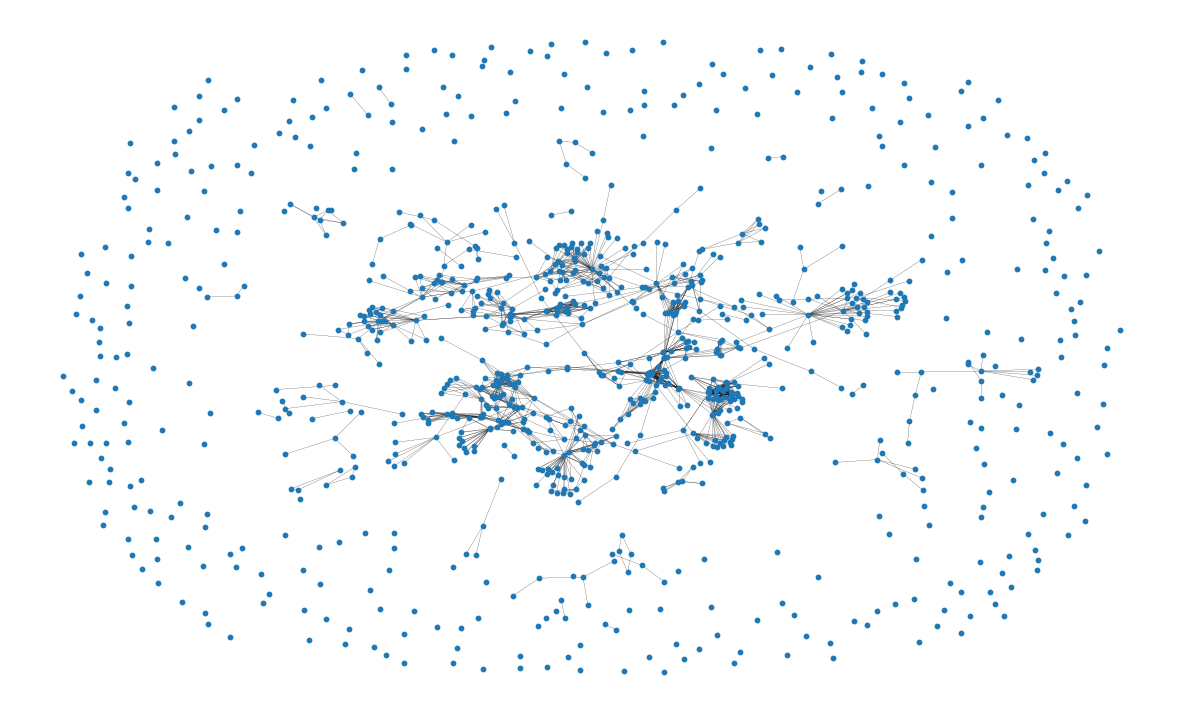

In [ ]:
plot_options = {"node_size": 10, "with_labels": False, "width": 0.15}
pos = nx.spring_layout(subgraph, iterations=15, seed=1234)
fig, ax = plt.subplots(figsize=(15, 9))
ax.axis("off")
nx.draw_networkx(subgraph, pos=pos, ax=ax, **plot_options)

Subgrafo con los nodos más conectados tiene 1000 nodos y 1477 aristas.


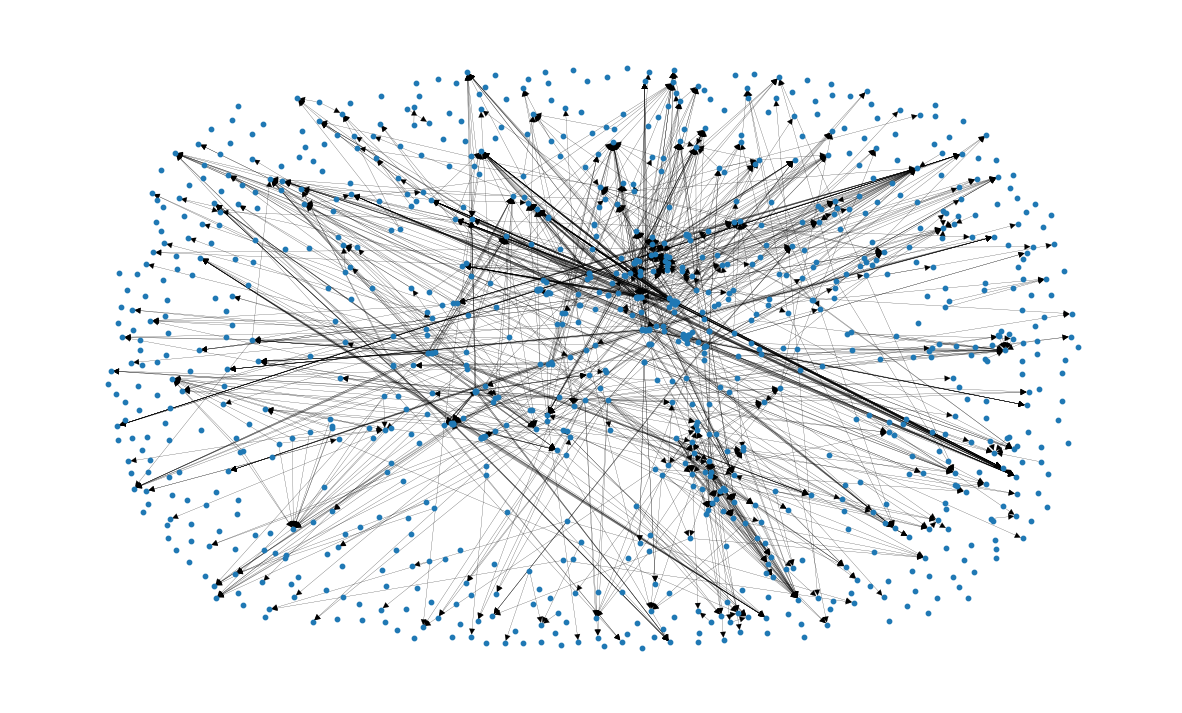

In [ ]:
# Obtener los grados totales (suma de in-degree y out-degree)
total_degrees = dict(G_Dir.degree())

# Ordenar los nodos por grado y seleccionar los 10,000 con mayor grado
top_nodes = [node for node, degree in sorted(total_degrees.items(), key=lambda x: x[1], reverse=True)[:1000]]

# Crear un subgrafo con esos nodos
subgraph = G_Dir.subgraph(top_nodes)

print(f"Subgrafo con los nodos más conectados tiene {subgraph.number_of_nodes()} nodos y {subgraph.number_of_edges()} aristas.")

plot_options = {"node_size": 10, "with_labels": False, "width": 0.15}
pos = nx.spring_layout(subgraph, iterations=15, seed=1234)
fig, ax = plt.subplots(figsize=(15, 9))
ax.axis("off")
nx.draw_networkx(subgraph, pos=pos, ax=ax, **plot_options)

Subgrafo Aleatorio

Subgrafo tiene 1000 nodos y 2 aristas.


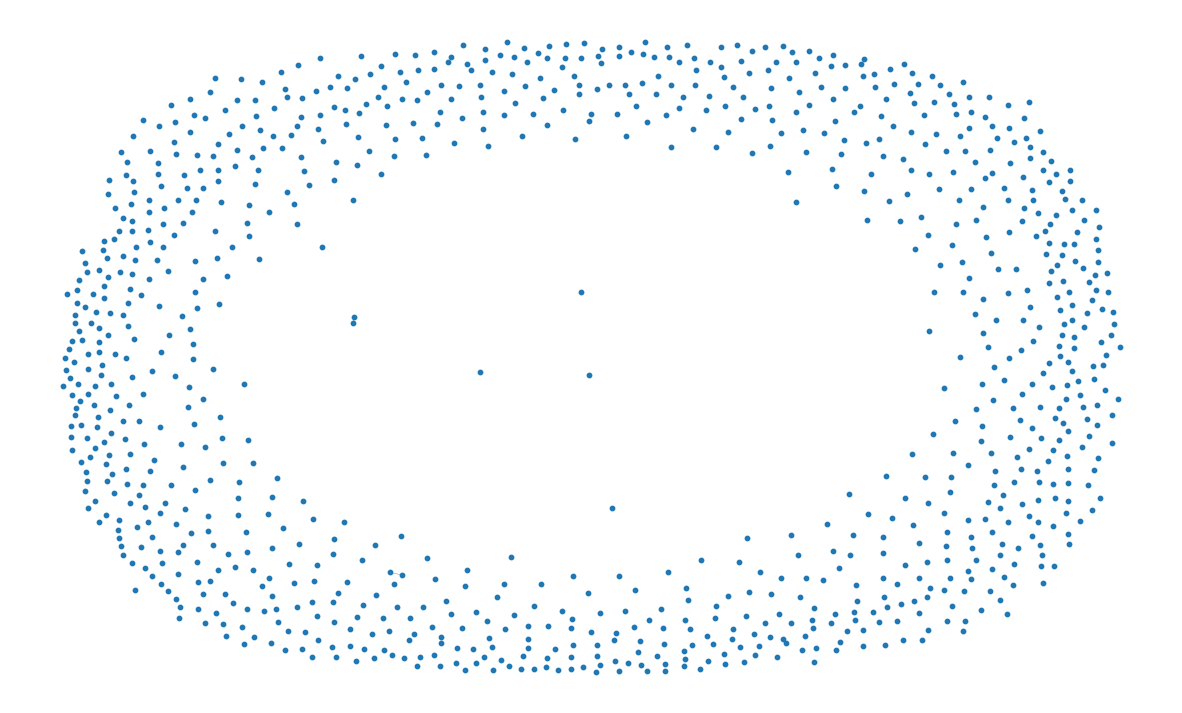

In [ ]:
import random

np.random.seed(42)
# Número de nodos que quieres seleccionar aleatoriamente (por ejemplo, 10,000)
sample_size = 1000

# Seleccionar una muestra aleatoria de nodos del grafo
sample_nodes = random.sample(list(G.nodes()), sample_size)

# Crear un subgrafo a partir de esos nodos
subgraph_random = G.subgraph(sample_nodes)

# Ahora puedes trabajar con este subgrafo más pequeño
print(f"Subgrafo tiene {subgraph_random.number_of_nodes()} nodos y {subgraph_random.number_of_edges()} aristas.")

plot_options = {"node_size": 10, "with_labels": False, "width": 0.15}
pos = nx.spring_layout(subgraph_random, iterations=15, seed=1234)
fig, ax = plt.subplots(figsize=(15, 9))
ax.axis("off")
nx.draw_networkx(subgraph_random, pos=pos, ax=ax, **plot_options)


Aleatorio por Aristas

Subgrafo tiene 1998 nodos y 1000 aristas.


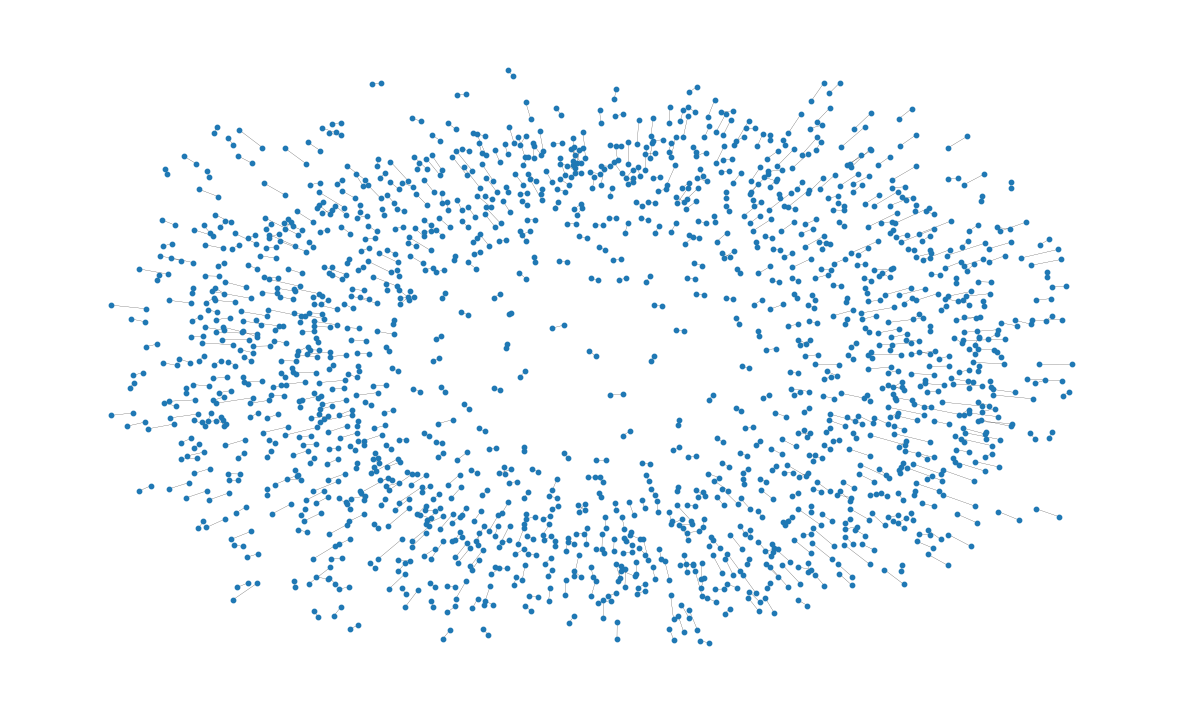

In [ ]:
import random
import matplotlib.pyplot as plt

# Fijar la semilla para reproducibilidad
np.random.seed(42)

# Número de aristas que quieres seleccionar aleatoriamente (por ejemplo, 1000)
sample_edge_size = 1000

# Seleccionar una muestra aleatoria de aristas del grafo
sample_edges = random.sample(list(G.edges()), sample_edge_size)

# Crear un subgrafo inducido por esas aristas
subgraph_edges = G.edge_subgraph(sample_edges).copy()

# Ahora puedes trabajar con este subgrafo más pequeño
print(f"Subgrafo tiene {subgraph_edges.number_of_nodes()} nodos y {subgraph_edges.number_of_edges()} aristas.")

# Visualizar el subgrafo
plot_options = {"node_size": 10, "with_labels": False, "width": 0.15}
pos = nx.spring_layout(subgraph_edges, iterations=15, seed=1234)
fig, ax = plt.subplots(figsize=(15, 9))
ax.axis("off")
nx.draw_networkx(subgraph_edges, pos=pos, ax=ax, **plot_options)
plt.show()


Aleatorio dirigido

Subgrafo tiene 1000 nodos y 0 aristas.


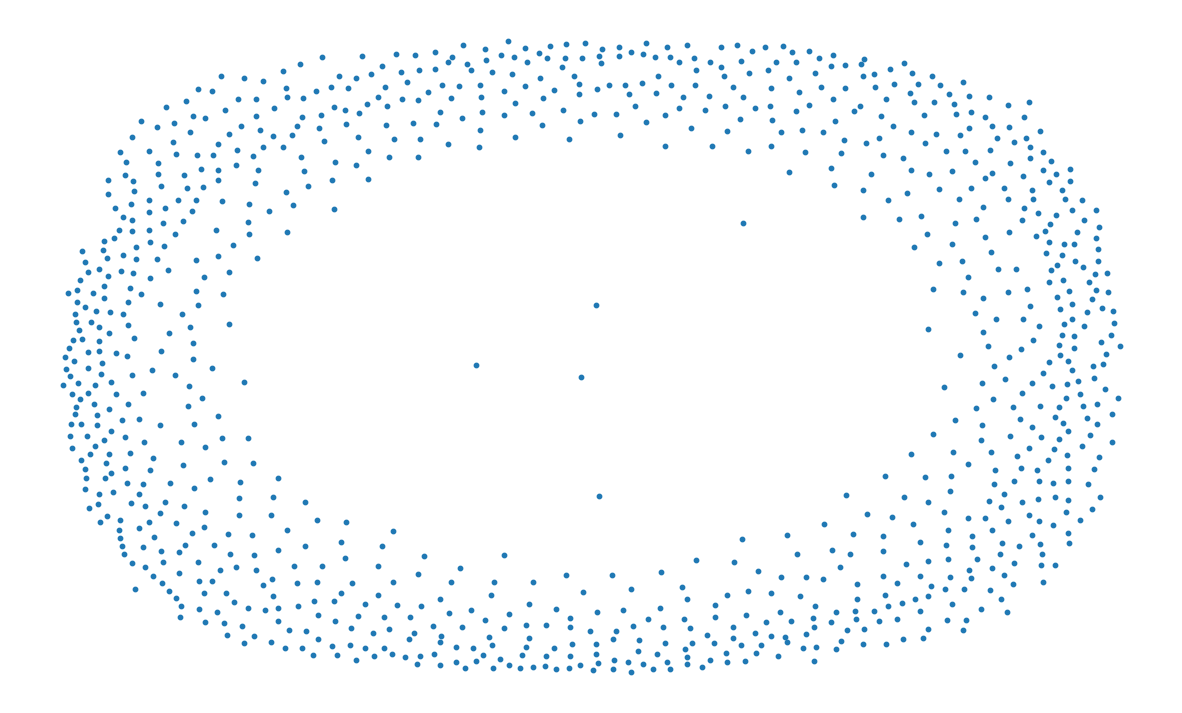

In [ ]:
import random

np.random.seed(42)
# Número de nodos que quieres seleccionar aleatoriamente (por ejemplo, 10,000)
sample_size = 1000

# Seleccionar una muestra aleatoria de nodos del grafo
sample_nodes = random.sample(list(G_Dir.nodes()), sample_size)

# Crear un subgrafo a partir de esos nodos
subgraph_random = G_Dir.subgraph(sample_nodes)

# Ahora puedes trabajar con este subgrafo más pequeño
print(f"Subgrafo tiene {subgraph_random.number_of_nodes()} nodos y {subgraph_random.number_of_edges()} aristas.")

plot_options = {"node_size": 10, "with_labels": False, "width": 0.15}
pos = nx.spring_layout(subgraph_random, iterations=15, seed=1234)
fig, ax = plt.subplots(figsize=(15, 9))
ax.axis("off")
nx.draw_networkx(subgraph_random, pos=pos, ax=ax, **plot_options)

SubGrafo mas conectado

In [ ]:
# no disponible para grafos no dirigidos
# Encontrar todos los componentes conectados en el grafo (en grafos dirigidos se usa weakly_connected)
components = list(nx.weakly_connected_components(G_Dir))

# Seleccionar el componente más grande
largest_component = max(components, key=len)

# Crear un subgrafo basado en el componente más grande
subgraph_conn = G_Dir.subgraph(largest_component)

print(f"El subgrafo más grande tiene {subgraph_conn.number_of_nodes()} nodos y {subgraph_conn.number_of_edges()} aristas.")


El subgrafo más grande tiene 3764116 nodos y 16511740 aristas.


In [ ]:
# Si estás trabajando con un grafo dirigido, obtener los componentes fuertemente conectados
strong_components = list(nx.strongly_connected_components(G_Dir))

# Seleccionar el componente más grande
largest_strong_component = max(strong_components, key=len)

# Crear un subgrafo con el componente fuertemente conectado más grande
subgraph_connected = G_Dir.subgraph(largest_strong_component)

print(f"Subgrafo conectado tiene {subgraph_connected.number_of_nodes()} nodos y {subgraph_connected.number_of_edges()} aristas.")


Subgrafo bfs_tree

In [9]:
# Paso 1: Seleccionar el nodo con mayor grado
degree_dict = dict(G.degree())
max_degree_node = max(degree_dict, key=degree_dict.get)

# Paso 2: Generar un subgrafo basado en BFS desde el nodo con mayor grado
def generate_bfs_subgraph(G, start_node, max_depth=3):
    bfs_nodes = list(nx.bfs_tree(G, start_node, depth_limit=max_depth).nodes)
    subgraph = G.subgraph(bfs_nodes)
    return subgraph

# Generar el subgrafo
subgraph_bfs = generate_bfs_subgraph(G, max_degree_node, max_depth=2)

print(f"Subgrafo conectado tiene {subgraph_bfs.number_of_nodes()} nodos y {subgraph_bfs.number_of_edges()} aristas.")



Subgrafo conectado tiene 5595 nodos y 28003 aristas.


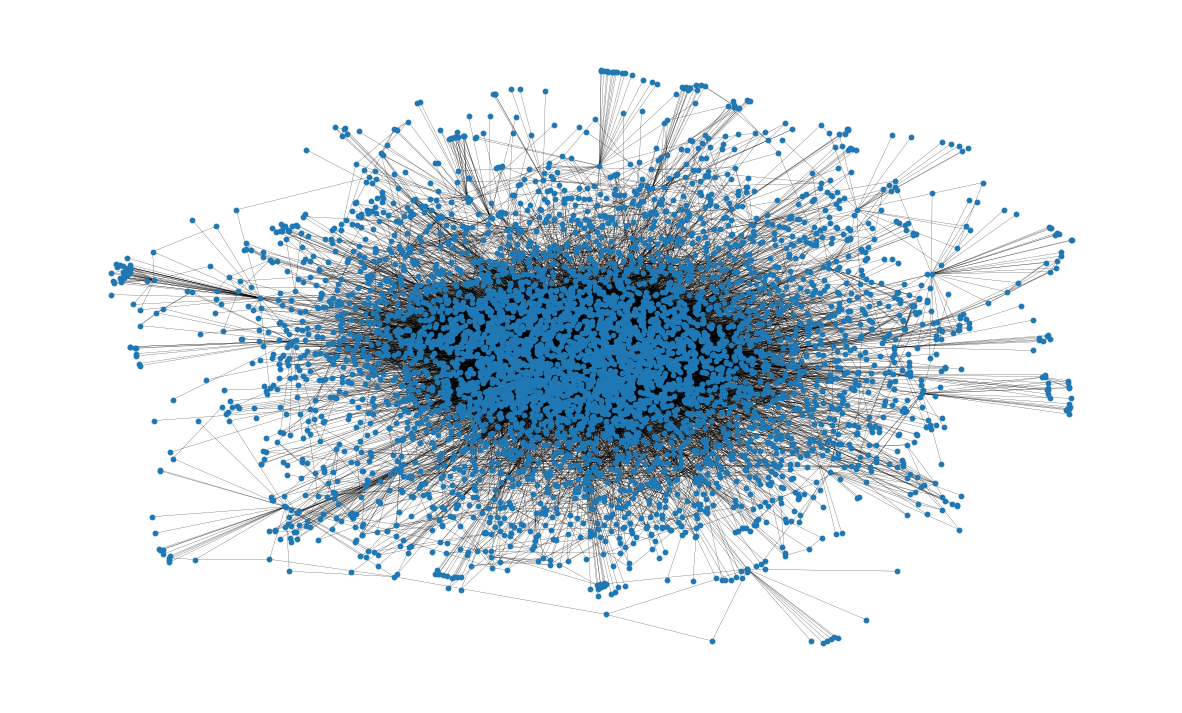

In [10]:
plot_options = {"node_size": 10, "with_labels": False, "width": 0.15}
pos = nx.spring_layout(subgraph_bfs, iterations=15, seed=1234)
fig, ax = plt.subplots(figsize=(15, 9))
ax.axis("off")
nx.draw_networkx(subgraph_bfs, pos=pos, ax=ax, **plot_options)

### Intentar Modelo Node TO VEC con subgrafo BFS dado que con el grafo completo falla por falta de ram

In [11]:
from node2vec import Node2Vec

node2vec = Node2Vec(subgraph_bfs, dimensions=32, walk_length=10, num_walks=10, p=2, q=1, workers=1)

model = node2vec.fit(window=10, min_count=1, batch_words=4)

Computing transition probabilities:   0%|          | 0/5595 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [00:05<00:00,  1.81it/s]


In [12]:
# Obtener el primer nodo del vocabulario
first_node = model.wv.index_to_key[0]
print(f"El primer nodo en el vocabulario es: {first_node}")

El primer nodo en el vocabulario es: 4723129


Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x78624ba801f0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.10/dist-packages/threadpoolctl.py", line 1175, in _make_controller_from_path
    lib_controller = controller_class(
  File "/usr/local/lib/python3.10/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
  File "/usr/lib/python3.10/ctypes/__init__.py", line 374, in __init__
    self._handle = _dlopen(self._name, mode)
OSError: dlopen() error
Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x78624ba801f0>
Traceback (most recent call last

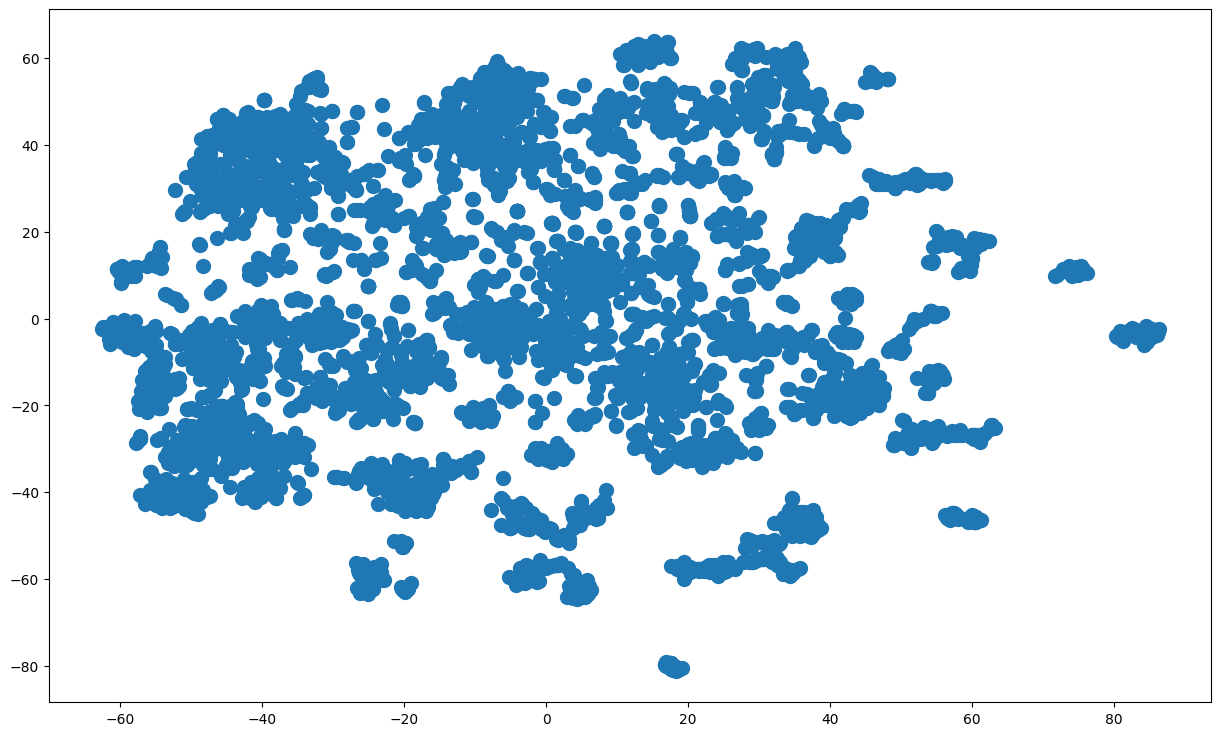

In [13]:
from sklearn.manifold import TSNE
import numpy as np

# Preprocess word vectors and label
nodes_wv = np.array([model.wv.get_vector(str(i)) for i in model.wv.index_to_key])

# Train TSNE
tsne = TSNE(n_components=2,
            learning_rate='auto',
            init='pca',
            random_state=0).fit_transform(nodes_wv)

# Plot TSNE
plt.figure(figsize=(15, 9))
plt.scatter(tsne[:, 0], tsne[:, 1], s=100)
plt.show()

In [14]:
# Obtener las patentes más similares a una patente dada
similar_patents = model.wv.most_similar('5618120')
print(similar_patents)

[('4778296', 0.9426211714744568), ('4983854', 0.9405212998390198), ('4591871', 0.9309433698654175), ('4265556', 0.9278477430343628), ('4639607', 0.9180600643157959), ('4795999', 0.8511937260627747), ('5486063', 0.8479617834091187), ('5150977', 0.8355385661125183), ('5193918', 0.795137345790863), ('5806992', 0.7944507598876953)]


In [17]:
def recommend_patent(patent_id):
    # Convertir el patent_id a string (si es necesario para Node2Vec)
    patent_id_str = str(patent_id)

    # Obtener las patentes más similares a la patente dada
    similar_patents = model.wv.most_similar(patent_id_str, topn=5)

    print(f"Patentes similares a {patent_id}:")

    # Iterar sobre las patentes recomendadas
    for id, similarity in similar_patents:
        print(f'Patente ID: {id}, Similitud: {similarity:.2f}')

In [18]:
recommend_patent('5618120')

Patentes similares a 5618120:
Patente ID: 4778296, Similitud: 0.94
Patente ID: 4983854, Similitud: 0.94
Patente ID: 4591871, Similitud: 0.93
Patente ID: 4265556, Similitud: 0.93
Patente ID: 4639607, Similitud: 0.92


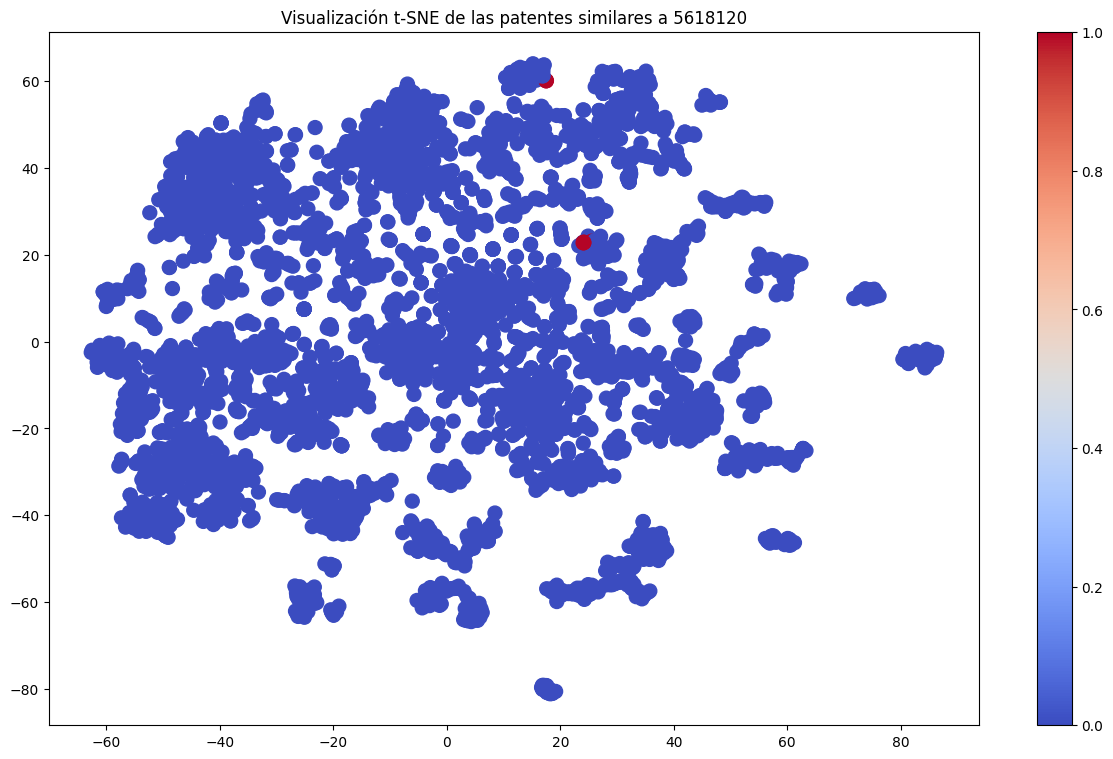

In [22]:
def create_labels(patent_id):
    # Convertir el patent_id a string (si es necesario)
    patent_id_str = str(patent_id)

    # Obtener las patentes más similares al patent_id
    similar_patents = model.wv.most_similar(patent_id_str, topn=10)
    similar_patent_ids = [int(pat[0]) for pat in similar_patents]  # Convertir a enteros

    # Crear una lista de etiquetas del mismo tamaño que el número de nodos
    labels = []
    for node in model.wv.index_to_key:
        if int(node) in similar_patent_ids:
            labels.append(1)  # Etiqueta 1 para patentes similares
        else:
            labels.append(0)  # Etiqueta 0 para el resto

    return labels

def plot_patents(patent_id):
    # Obtener los vectores de los nodos (patentes) aprendidos por Node2Vec
    nodes_wv = model.wv.vectors  # Vectores de las patentes

    # Aplicar t-SNE para reducir dimensiones a 2D
    tsne = TSNE(n_components=2, learning_rate='auto', init='pca', random_state=0).fit_transform(nodes_wv)

    # Crear etiquetas para la visualización
    labels = create_labels(patent_id)  # Etiquetas correspondientes a cada nodo

    # Asegurarse de que las etiquetas y los vectores tengan el mismo tamaño
    if len(labels) != tsne.shape[0]:
        raise ValueError(f"Inconsistencia: {len(labels)} etiquetas para {tsne.shape[0]} nodos.")

    # Visualizar el t-SNE
    plt.figure(figsize=(15, 9))
    plt.scatter(tsne[:, 0], tsne[:, 1], s=100, c=labels, cmap="coolwarm")
    plt.colorbar()  # Añadir barra de colores para las etiquetas
    plt.title(f"Visualización t-SNE de las patentes similares a {patent_id}")
    plt.show()

# Ejemplo de uso:
plot_patents(5618120)